#Install and Import

In [4]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Read Data and Preprocessing

In [5]:
df = pd.read_csv('MP2_Data.csv')
print(f"Any missing value? {df.isnull().values.any()} \n")
print(f"Any duplicate value? {df.duplicated().values.any()} \n")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]} \n")

df.head()

Any missing value? False 

Any duplicate value? False 

Number of rows: 107
Number of columns: 48 



,ID,Week2_Quiz1,Week3_MP1,Week3_PR1,Week5_MP2,Week5_PR2,Week7_MP3,Week7_PR3,Week4_Quiz2,Week6_Quiz3,...,Week7_Stat3,Week8_Stat0,Week8_Stat1,Week8_Stat2,Week8_Stat3,Week9_Stat0,Week9_Stat1,Week9_Stat2,Week9_Stat3,Grade
0,ML-2020-1,5.00,15.0,5.0,16.09,5.00,21.88,5.0,5.00,5.0,...,0,5,4,0,4,8,6,1,0,4
1,ML-2020-2,3.33,15.0,5.0,17.83,5.00,22.27,5.0,4.00,5.0,...,8,5,2,0,0,25,3,2,5,4
2,ML-2020-3,1.67,13.0,5.0,15.22,5.00,27.05,2.5,5.00,5.0,...,0,8,2,0,0,9,0,1,0,3
3,ML-2020-4,2.50,14.0,5.0,10.00,5.00,31.02,5.0,3.13,5.0,...,4,10,0,0,0,7,6,0,0,3
4,ML-2020-6,0.00,15.0,5.0,12.17,4.93,15.91,5.0,4.67,5.0,...,6,8,5,1,1,5,3,1,0,2


In [6]:
df.columns

Index(['ID', 'Week2_Quiz1', 'Week3_MP1', 'Week3_PR1', 'Week5_MP2', 'Week5_PR2',
       'Week7_MP3', 'Week7_PR3', 'Week4_Quiz2', 'Week6_Quiz3', 'Week8_Total',
       'Week1_Stat0', 'Week1_Stat1', 'Week1_Stat2', 'Week1_Stat3',
       'Week2_Stat0', 'Week2_Stat1', 'Week2_Stat2', 'Week2_Stat3',
       'Week3_Stat0', 'Week3_Stat1', 'Week3_Stat2', 'Week3_Stat3',
       'Week4_Stat0', 'Week4_Stat1', 'Week4_Stat2', 'Week4_Stat3',
       'Week5_Stat0', 'Week5_Stat1', 'Week5_Stat2', 'Week5_Stat3',
       'Week6_Stat0', 'Week6_Stat1', 'Week6_Stat2', 'Week6_Stat3',
       'Week7_Stat0', 'Week7_Stat1', 'Week7_Stat2', 'Week7_Stat3',
       'Week8_Stat0', 'Week8_Stat1', 'Week8_Stat2', 'Week8_Stat3',
       'Week9_Stat0', 'Week9_Stat1', 'Week9_Stat2', 'Week9_Stat3', 'Grade'],
      dtype='object')

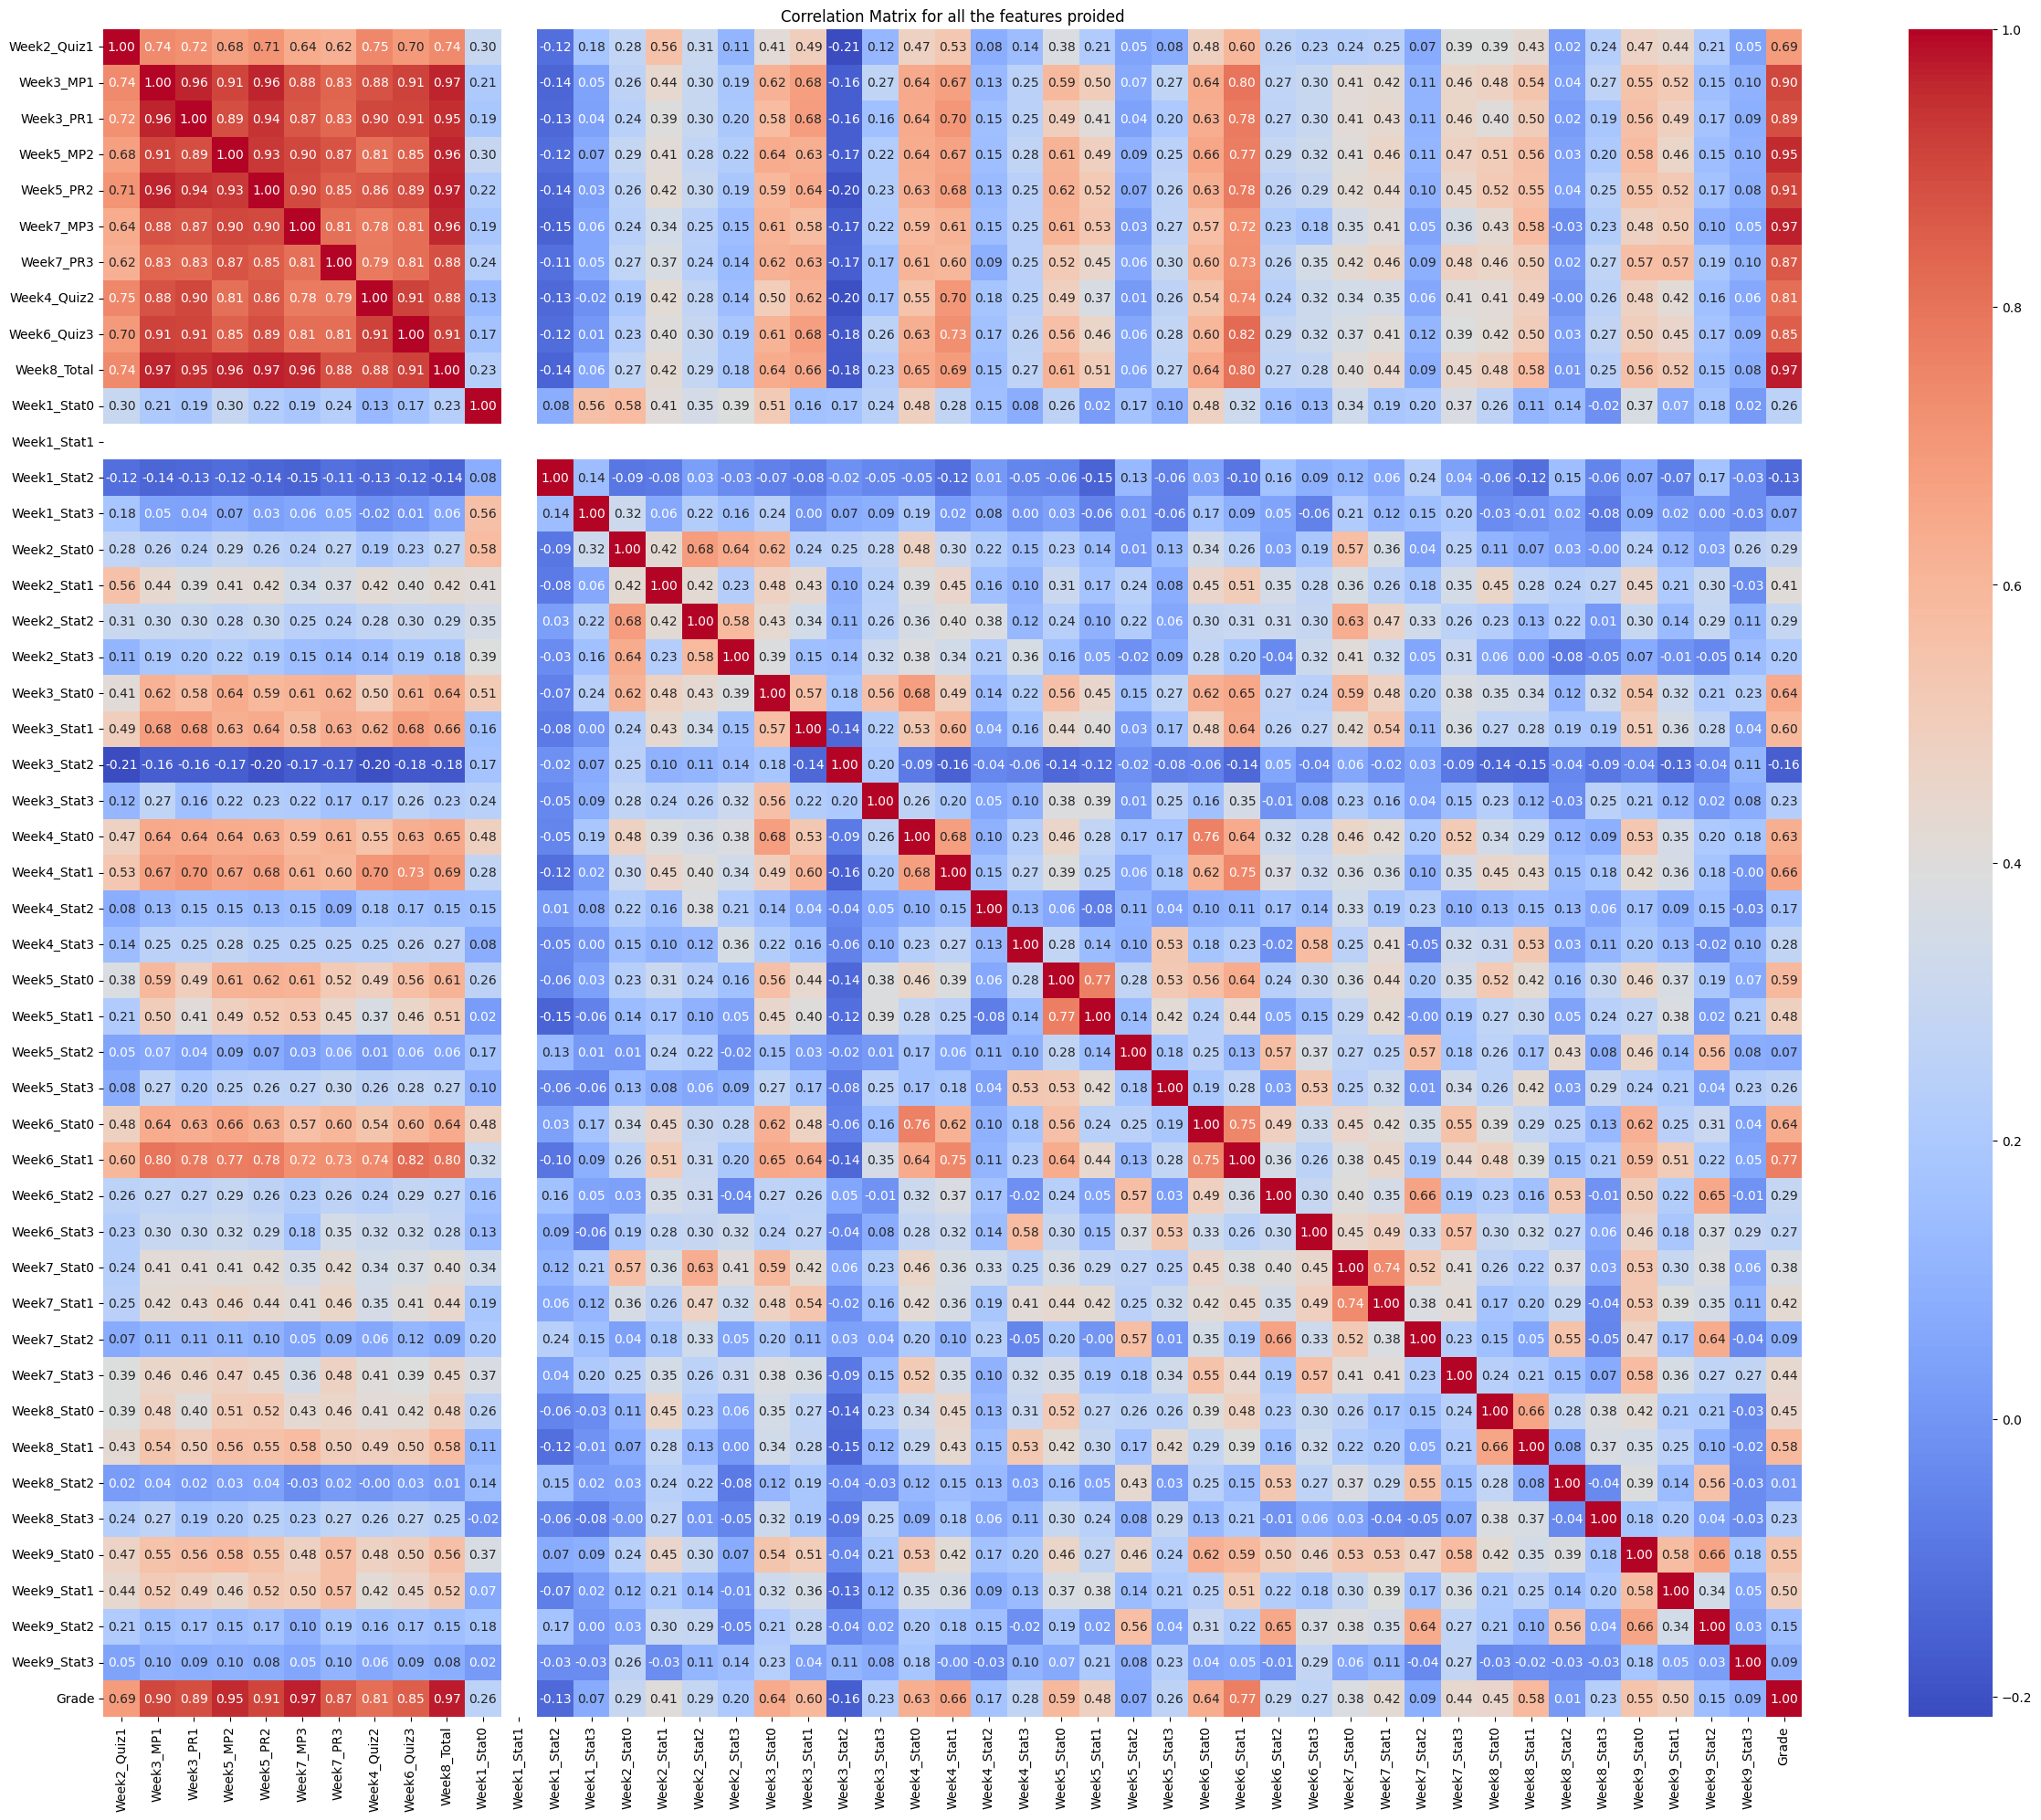

In [7]:
df.drop('ID', axis=1, inplace=True)
corr = df.corr()
plt.figure(figsize=(30, 24))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix for all the features proided")
plt.show()

In [8]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print("Constant columns:", constant_cols)
stat_columns = [col for col in df.columns if 'Stat' in col]
df.drop(columns=constant_cols+stat_columns, axis=1, inplace=True)
df.head()

Constant columns: ['Week1_Stat1']


,Week2_Quiz1,Week3_MP1,Week3_PR1,Week5_MP2,Week5_PR2,Week7_MP3,Week7_PR3,Week4_Quiz2,Week6_Quiz3,Week8_Total,Grade
0,5.00,15.0,5.0,16.09,5.00,21.88,5.0,5.00,5.0,82.97,4
1,3.33,15.0,5.0,17.83,5.00,22.27,5.0,4.00,5.0,82.43,4
2,1.67,13.0,5.0,15.22,5.00,27.05,2.5,5.00,5.0,79.44,3
3,2.50,14.0,5.0,10.00,5.00,31.02,5.0,3.13,5.0,80.65,3
4,0.00,15.0,5.0,12.17,4.93,15.91,5.0,4.67,5.0,67.68,2


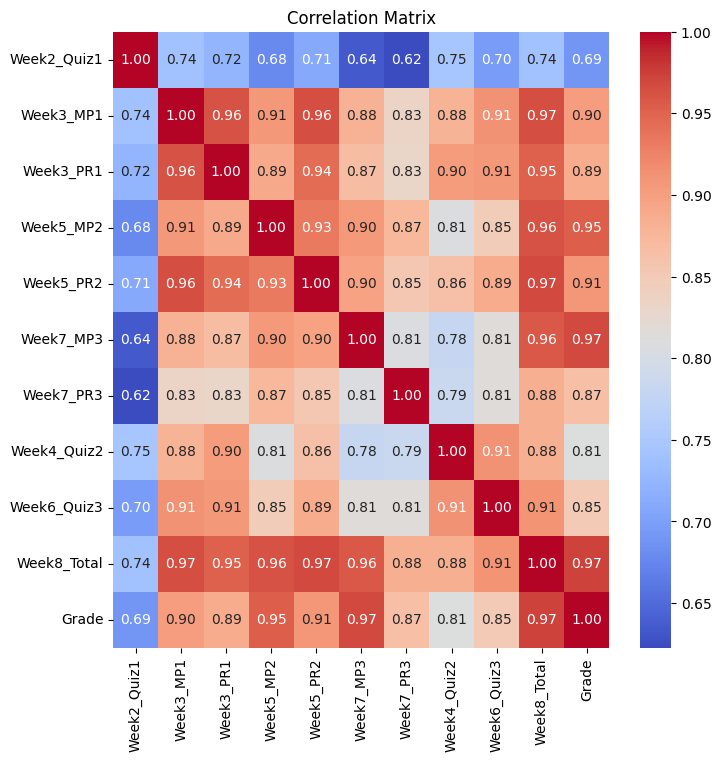

In [9]:
corr = df.corr()
plt.figure(figsize=(8, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Data Split

In [10]:
x = df.drop('Grade', axis=1)
y = df['Grade']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=24)
print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)

Train shape: (74, 10) (74,)
Test shape: (33, 10) (33,)


#Model Training

## K-Nearest Neighbors (KNN)

In [11]:
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='uniform',
)

knn_model.fit(x_train, y_train)
y_pred_knn = knn_model.predict(x_test)

accuracy_knn = accuracy_score(y_test, y_pred_knn) * 100
print(f"kNN Accuracy = {accuracy_knn:.2f}%\n")

kNN Accuracy = 93.94%



##Random Forest

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=24
)

rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf) * 100
print(f"Classification Accuracy = {accuracy_rf:.2f} %")

Classification Accuracy = 96.97 %


#Visualization

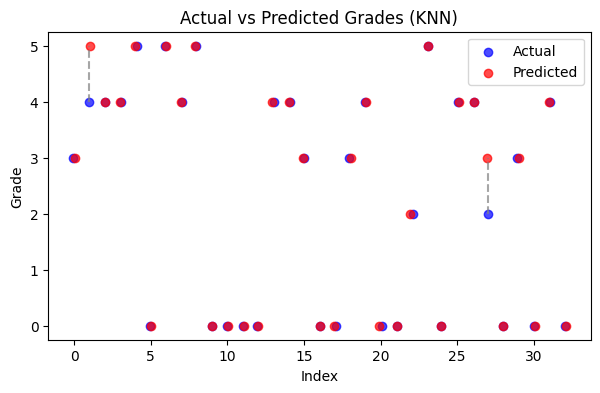

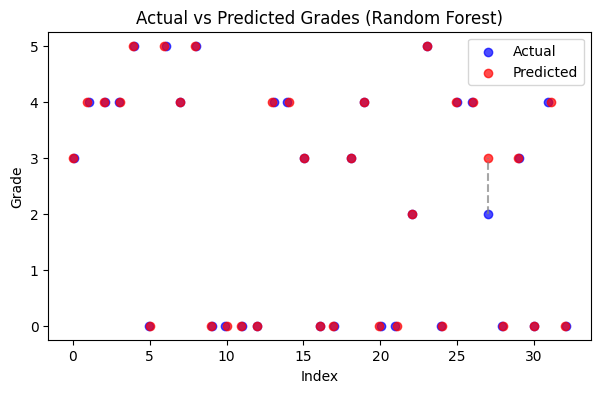

In [13]:
def plot_actual_vs_predicted(y_test, y_pred, title):
    jitter = 0.1
    x = np.arange(len(y_test))
    plt.figure(figsize=(7,4))

    plt.scatter(x + np.random.uniform(-jitter, jitter, len(y_test)), y_test.values, color='blue', label='Actual', alpha=0.7)
    plt.scatter(x + np.random.uniform(-jitter, jitter, len(y_pred)), y_pred, color='red', label='Predicted', alpha=0.7)
    for i in range(len(x)):
        plt.plot([x[i], x[i]], [y_test.values[i], y_pred[i]], color='gray', linestyle='--', alpha=0.7)

    plt.xlabel('Index')
    plt.ylabel('Grade')
    plt.title(title)
    plt.legend()
    plt.show()

plot_actual_vs_predicted(y_test, y_pred_knn, title='Actual vs Predicted Grades (KNN)')
plot_actual_vs_predicted(y_test, y_pred_rf, title='Actual vs Predicted Grades (Random Forest)')

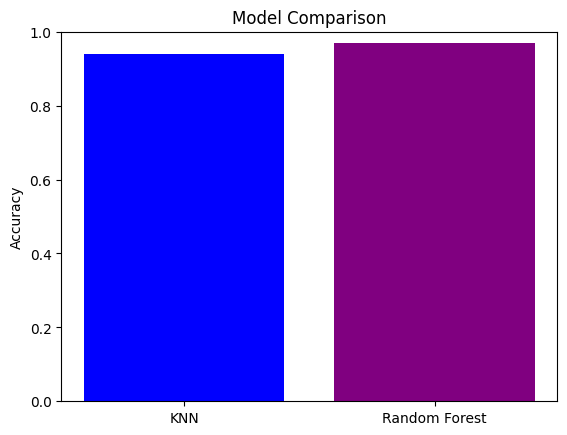

In [14]:
models = ['KNN', 'Random Forest']
accuracies = [accuracy_knn/100, accuracy_rf/100]

plt.bar(models, accuracies, color=['blue','purple'])
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.ylim(0,1)
plt.show()


# Important Features

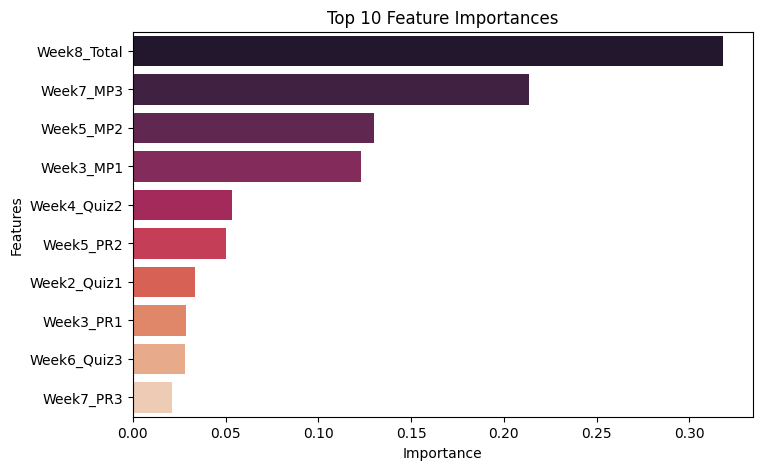

In [15]:
feature_importances = pd.Series(rf_model.feature_importances_, index=x_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)[:10]

plt.figure(figsize=(8,5))
sns.barplot(
    x=feature_importances.values,
    y=feature_importances.index,
    palette="rocket",
    hue=feature_importances.index,
)
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()
